In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("funnel_events_sample_.csv")

df.head()

,user_id,step,timestamp
0,U018,visited_site,20-07-2026 03:50
1,U040,signup_started,20-07-2026 03:55
2,U029,signup_started,20-07-2026 03:57
3,U160,visited_site,20-07-2026 03:34
4,U011,details_filled,20-07-2026 04:21


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

In [3]:
print("Dataset Shape:")


Dataset Shape:


In [4]:
print(df.shape)

(542, 3)


In [5]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['user_id', 'step', 'timestamp'], dtype='str')


In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
user_id      str
step         str
timestamp    str
dtype: object


In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
user_id      0
step         0
timestamp    0
dtype: int64


In [9]:
# Convert timestamp to datetime

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)



In [17]:


# Check duplicate user-step records
duplicate_count = df.duplicated(subset=["user_id", "step"]).sum()

print(f"Duplicate user-step records: {duplicate_count}")

# Remove duplicates
df = df.drop_duplicates(subset=["user_id", "step"])

print("Dataset Shape:", df.shape)

Duplicate user-step records: 0
Dataset Shape: (542, 3)


In [11]:
# Define funnel order

funnel_order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

# Count unique users at each stage

funnel = (
    df.groupby("step")["user_id"]
      .nunique()
      .reindex(funnel_order)
      .reset_index()
)

funnel.columns = ["Stage", "Users"]

funnel


,Stage,Users
0,visited_site,200
1,signup_started,150
2,details_filled,96
3,email_verified,52
4,purchase_completed,44


In [12]:
conversion = []

for i in range(len(funnel)):
    if i == 0:
        conversion.append(100.0)
    else:
        rate = (
            funnel.loc[i, "Users"] /
            funnel.loc[i-1, "Users"]
        ) * 100

        conversion.append(round(rate,2))

funnel["Conversion Rate (%)"] = conversion

funnel

,Stage,Users,Conversion Rate (%)
0,visited_site,200,100.00
1,signup_started,150,75.00
2,details_filled,96,64.00
3,email_verified,52,54.17
4,purchase_completed,44,84.62


In [13]:
drop = []

for i in range(len(funnel)):
    if i == 0:
        drop.append(0)
    else:
        loss = (
            funnel.loc[i-1,"Users"]
            -
            funnel.loc[i,"Users"]
        )

        drop.append(loss)

funnel["Drop-off Users"] = drop

funnel

,Stage,Users,Conversion Rate (%),Drop-off Users
0,visited_site,200,100.00,0
1,signup_started,150,75.00,50
2,details_filled,96,64.00,54
3,email_verified,52,54.17,44
4,purchase_completed,44,84.62,8


In [14]:
largest = funnel["Drop-off Users"].idxmax()

print("="*40)

print("BIGGEST FUNNEL DROP-OFF")

print("="*40)

print("Stage :",
      funnel.loc[largest,"Stage"])

print("Users Lost :",
      funnel.loc[largest,"Drop-off Users"])

print("="*40)

BIGGEST FUNNEL DROP-OFF
Stage : details_filled
Users Lost : 54


## Recommendation

The largest drop-off occurs between **Signup Started** and **Details Filled**, where 54 users leave the funnel. This suggests that users may find the form lengthy or difficult to complete. Simplifying the form, reducing mandatory fields, improving validation messages, and optimizing page performance could help improve conversion at this stage.

In [21]:
# Calculate overall conversion rate
overall_conversion = (
    funnel.loc[funnel["Stage"] == "purchase_completed", "Users"].values[0]
    /
    funnel.loc[funnel["Stage"] == "visited_site", "Users"].values[0]
) * 100

print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

Overall Conversion Rate: 22.00%


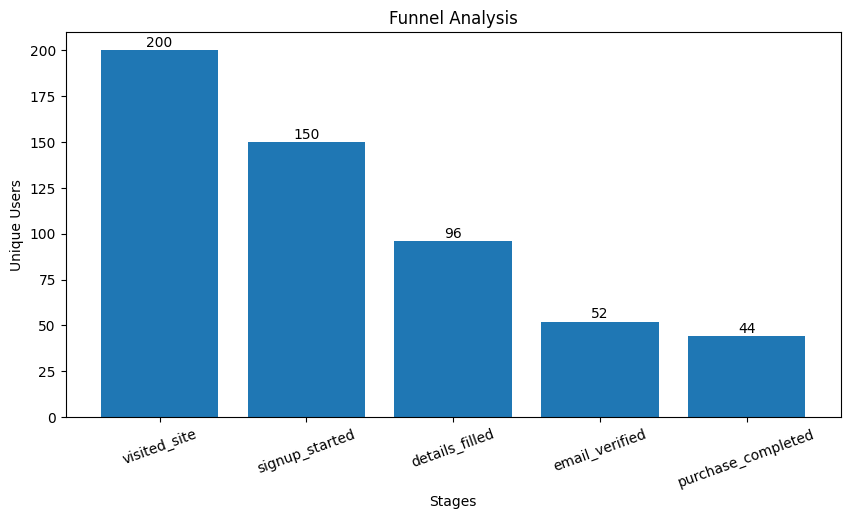

In [18]:
plt.figure(figsize=(10,5))

bars = plt.bar(funnel["Stage"], funnel["Users"])

plt.title("Funnel Analysis")
plt.xlabel("Stages")
plt.ylabel("Unique Users")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha="center"
    )

plt.xticks(rotation=20)
plt.show()

In [19]:
print("Final Funnel Analysis")
print(funnel.to_string(index=False))

Final Funnel Analysis
             Stage  Users  Conversion Rate (%)  Drop-off Users
      visited_site    200               100.00               0
    signup_started    150                75.00              50
    details_filled     96                64.00              54
    email_verified     52                54.17              44
purchase_completed     44                84.62               8


In [20]:
funnel.to_csv("Funnel_Analysis_Result.csv", index=False)

print("Analysis saved successfully.")

Analysis saved successfully.


# Funnel Drop-off Analysis

## Objective

Analyze user behavior across a signup funnel and identify the stage with the highest user drop-off.

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Steps Performed

- Data Cleaning
- Duplicate Handling
- Funnel Analysis
- Conversion Rate Calculation
- Drop-off Analysis
- Data Visualization

## Results

| Stage | Users | Conversion |
|-------|-------|------------|
|Visited Site|200|100%|
|Signup Started|150|75%|
|Details Filled|96|64%|
|Email Verified|52|54.17%|
|Purchase Completed|44|84.62%|

### Biggest Drop-off

Users dropped the most between **Signup Started** and **Details Filled** (54 users).

## Recommendation

Simplify the details form, improve validation messages, reduce unnecessary fields, and optimize page performance to improve conversions.

# Recommendation

The largest drop-off occurs between **Signup Started** and **Details Filled**, where **54 users** leave the funnel.

Possible reasons:
- Long registration form
- Too many mandatory fields
- Poor mobile experience
- Slow page loading

Suggested Improvements:
- Reduce the number of required fields.
- Enable Google/Apple one-click signup.
- Show a progress indicator.
- Improve page loading speed.

These changes can improve the conversion rate and reduce user abandonment.

# Conclusion

### Approach

- Loaded the dataset using Pandas.
- Checked shape, columns, data types and missing values.
- Converted timestamp into datetime format.
- Removed duplicate user-step events.
- Counted unique users at each funnel stage.
- Calculated stage-to-stage conversion rates.
- Identified the largest drop-off stage.
- Visualized the funnel using a bar chart.
- Suggested business recommendations to improve conversions.

# Conclusion

The funnel analysis shows:

- Total Visitors: 200
- Signup Started: 150 (75%)
- Details Filled: 96 (64%)
- Email Verified: 52 (54.17%)
- Purchase Completed: 44 (84.62%)

The biggest drop-off occurs at the **Details Filled** stage, where **54 users** leave the funnel.

Improving the registration form and simplifying the onboarding process can significantly increase the overall conversion rate.